# MỤC LỤC - PHÂN TÍCH DỮ LIỆU VÀ XÂY DỰNG MÔ HÌNH MACHINE LEARNING DỰ ĐOÁN KHÁCH HÀNG RỜI ĐI 

*Note: Việc phân tích được thực hiện dựa trên tập dữ liệu " Telco Customer Churn-LogisticRegression"
1. Tìm hiểu Dataset và phân tích tổng quan
2. Tiền xử lý dữ liệu
3. Phân tích chi tiết và trực quan hóa
4. Xây dựng mô hình Machine Learning


I. KHAI BÁO THƯ VIỆN SỬ DỤNG

In [2]:

# 1. XỬ LÝ & LÀM SẠCH DỮ LIỆU
import pandas as pd
import numpy as np
import os

# 2. TRỰC QUAN HÓA DỮ LIỆU (EDA)
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# 3. TIỀN XỬ LÝ và CÂN BẰNG DỮ LIỆU
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# 4. MÔ HÌNH MACHINE LEARNING
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC


# 5. ĐÁNH GIÁ MÔ HÌNH và TIỆN ÍCH
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)
from scipy import stats
import warnings
warnings.filterwarnings('ignore') # Tắt các cảnh báo không cần thiết

# Cấu hình hiển thị các quan sát và thuộc tính 
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x) # Định dạng số thực 3 chữ số thập phân

print(" Hoàn thành thiết lập môi trường ! ")

 Hoàn thành thiết lập môi trường ! 


II. XỬ LÝ DỮ LIỆU THÔ VÀ TÌM HIỂU THUỘC TÍNH

In [3]:
# 1. Kiểm tra bộ dữ liệu 
file_Name = r'Telco_Customers_Churn_Dataset.csv'
df = pd.read_csv(file_Name)

print(f" Bộ dữ liệu 'Telco Customers Churn' đã được tải lên hoàn tất !")
print(f" Dataset có tổng cộng {df.shape[0]} dòng và {df.shape[1]} thuộc tính. \n")

# 2. Xác đinh thông tin các thuộc tính của dữ liệu
print("Kiểu dữ liệu của các thuộc tính:")
for col_name, dtype in df.dtypes.items():
    print(f"    {col_name:<25} {dtype}") 

# 3. KIỂM TRA DÒNG TRÙNG LẶP
print(f"\n Số dòng bị trùng lặp là: {df.duplicated().sum()}")
print(f" Số khách hàng (CustomersID) bị trùng lặp là: {df['customerID'].duplicated().sum()}")

# 4. KIỂM TRA THUỘC TÍNH BỊ THIẾU DỮ LIỆU - NaN
columns_is_null = df.columns[df.isnull().any()].tolist()

if columns_is_null:
    print(" Các thuộc tính bị thiếu dữ liệu:")
    for col in columns_is_null:
        print(f"    - {col}")
else:
    print(" Không có thuộc tính nào bị thiếu dữ liệu ")

# 5. PHÁT HIỆN MISSING VALUE ẨN TRONG BIẾN TotalCharges
temp = pd.to_numeric(df['TotalCharges'], errors='coerce')
null_Value = temp.isnull()
print(f"\n Số dòng Missing Value ẩn trong TotalCharges: {null_Value.sum()}")
print(" Đặc điểm các dòng lỗi (kiểm tra giả thuyết liên quan đến tenure):")
print(df.loc[null_Value, ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

# Ép kiểu thuộc tính TotalChanges thành float64 và khoảng trắng thành naN
df1 = df.copy()
df1['TotalCharges'] = pd.to_numeric(df1['TotalCharges'], errors='coerce').fillna(0) #Thay giá trị 0

print("\n KẾT QUẢ 11 DÒNG TRONG DF1 SAU KHI ĐÃ ĐƯỢC THAY THẾ BẰNG 0:")
print(df1.loc[null_Value, ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

# 6. Xóa thuộc tính CustomerID
df1.drop(columns=['customerID'], inplace=True)
print("\n Đã xóa cột CustomerID !")
print(f" Dataset có tổng cộng {df1.shape[0]} dòng và {df1.shape[1]} thuộc tính. \n")

# Lưu df1 thành file CSV
df1.to_csv('Telco Customers Churn Dataset 1.csv', index=False, encoding='utf-8-sig')
print(" Đã xuất dữ liệu ra file 'Telco Customers Churn Dataset 1.csv' thành công!")


 Bộ dữ liệu 'Telco Customers Churn' đã được tải lên hoàn tất !
 Dataset có tổng cộng 7043 dòng và 21 thuộc tính. 

Kiểu dữ liệu của các thuộc tính:
    customerID                object
    gender                    object
    SeniorCitizen             int64
    Partner                   object
    Dependents                object
    tenure                    int64
    PhoneService              object
    MultipleLines             object
    InternetService           object
    OnlineSecurity            object
    OnlineBackup              object
    DeviceProtection          object
    TechSupport               object
    StreamingTV               object
    StreamingMovies           object
    Contract                  object
    PaperlessBilling          object
    PaymentMethod             object
    MonthlyCharges            float64
    TotalCharges              object
    Churn                     object

 Số dòng bị trùng lặp là: 0
 Số khách hàng (Custome

### Phân tích thống kê biến mục tiêu Churn



Phân phối biến mục tiêu Churn:
       Số lượng  Tỷ lệ (%)
Churn                     
No         5174     73.460
Yes        1869     26.540


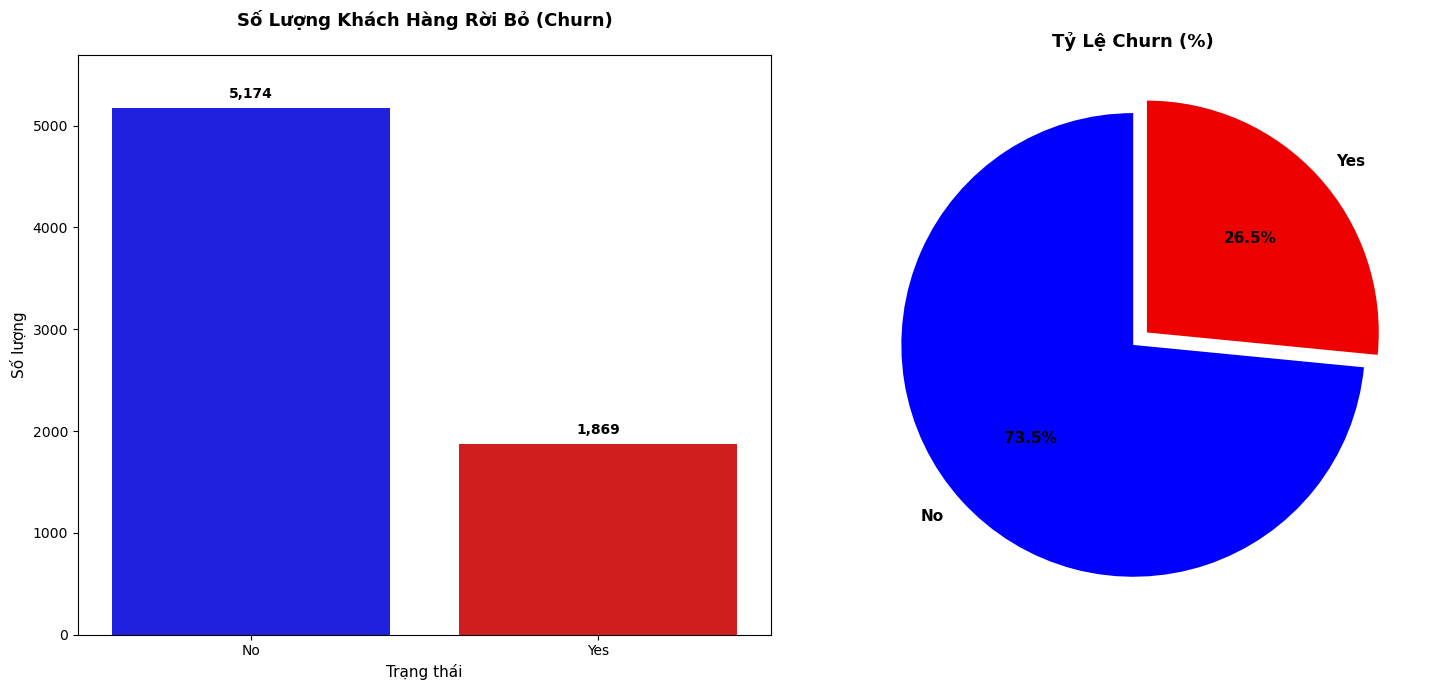

In [4]:
'''
PHÂN TÍCH ĐƠN BIẾN 
'''
df1 = pd.read_csv('Telco Customers Churn Dataset 1.csv')
df1['Churn_binary'] = df1['Churn'].map({'Yes': 1, 'No': 0})

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = ['gender','SeniorCitizen','Partner','Dependents','PhoneService','MultipleLines',
            'InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport',
            'StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod']

# ---------- 4.1.2 PHÂN TÍCH ĐƠN BIẾN ----------
churn_dist = pd.DataFrame({
    'Số lượng': df1['Churn'].value_counts(),
    'Tỷ lệ (%)': (df1['Churn'].value_counts(normalize=True) * 100).round(2)
})
print(f"\nPhân phối biến mục tiêu Churn:\n{churn_dist}")

# Tạo khung vẽ 1 hàng 2 cột
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
palette = ['#0000FF', '#EE0000'] # Xanh dương (No) - Đỏ (Yes)

# 1. Biểu đồ cột (Số lượng & Tỷ lệ %)
axes[0].set_ylim(0, churn_dist['Số lượng'].max() * 1.1)
ax1 = sns.barplot(x=churn_dist.index, y='Số lượng', data=churn_dist, ax=axes[0], palette=palette)
axes[0].set_title('Số Lượng Khách Hàng Rời Bỏ (Churn)\n', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Trạng thái', fontsize=11)
axes[0].set_ylabel('Số lượng', fontsize=11,)

# Hiển thị số liệu chi tiết trên đầu mỗi cột
total = churn_dist['Số lượng'].sum()
for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(f'{int(height):,}',
                 (p.get_x() + p.get_width() / 2., height),
                 ha='center', va='bottom', fontsize=10, fontweight='bold', 
                 xytext=(0, 5), textcoords='offset points')

# 2. Biểu đồ tròn (Tỷ lệ phần trăm %)
axes[1].pie(churn_dist['Tỷ lệ (%)'], labels=churn_dist.index, autopct='%1.1f%%',
            startangle=90, colors=palette, explode=(0, 0.08),
            textprops={'fontsize': 11, 'weight': 'bold'})
axes[1].set_title('Tỷ Lệ Churn (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


### Phân tích đơn biến cho các biến định lượng


=== BẢNG THỐNG KÊ MÔ TẢ BIẾN TENURE ===
          Chỉ số Thống kê  Giá trị (Tháng)
        Trung bình (Mean)           32.370
        Trung vị (Median)           29.000
           Nhỏ nhất (Min)            0.000
           Lớn nhất (Max)           72.000
      Độ lệch chuẩn (Std)           24.560
        Tứ phân vị 1 (Q1)            9.000
        Tứ phân vị 3 (Q3)           55.000
  Khoảng tứ phân vị (IQR)           46.000
       Độ lệch (Skewness)            0.240
Độ nhọn (Excess Kurtosis)           -1.390


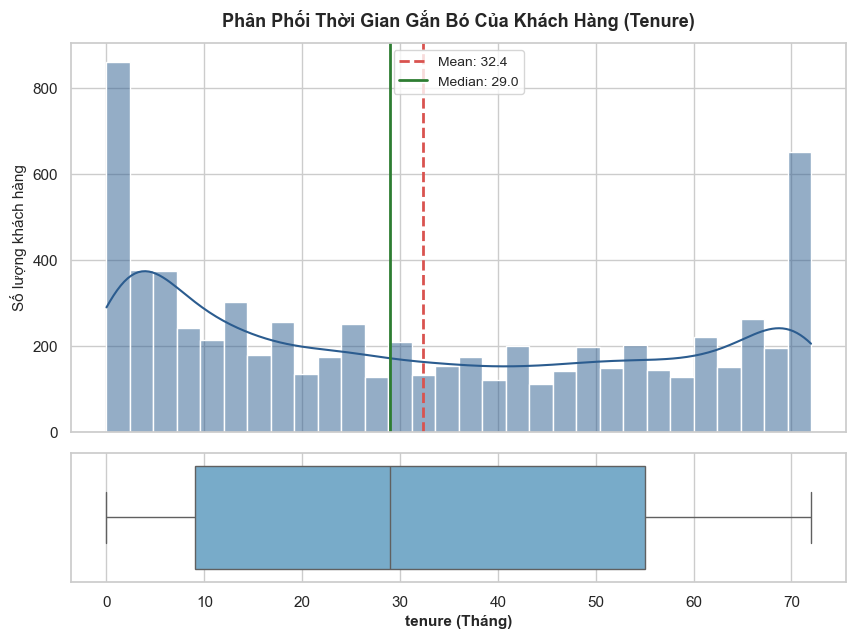



=== BẢNG THỐNG KÊ MÔ TẢ BIẾN MONTHLYCHARGES ===
          Chỉ số Thống kê  Giá trị (USD)
        Trung bình (Mean)         64.760
        Trung vị (Median)         70.350
           Nhỏ nhất (Min)         18.250
           Lớn nhất (Max)        118.750
      Độ lệch chuẩn (Std)         30.090
        Tứ phân vị 1 (Q1)         35.500
        Tứ phân vị 3 (Q3)         89.850
  Khoảng tứ phân vị (IQR)         54.350
       Độ lệch (Skewness)         -0.220
Độ nhọn (Excess Kurtosis)         -1.260


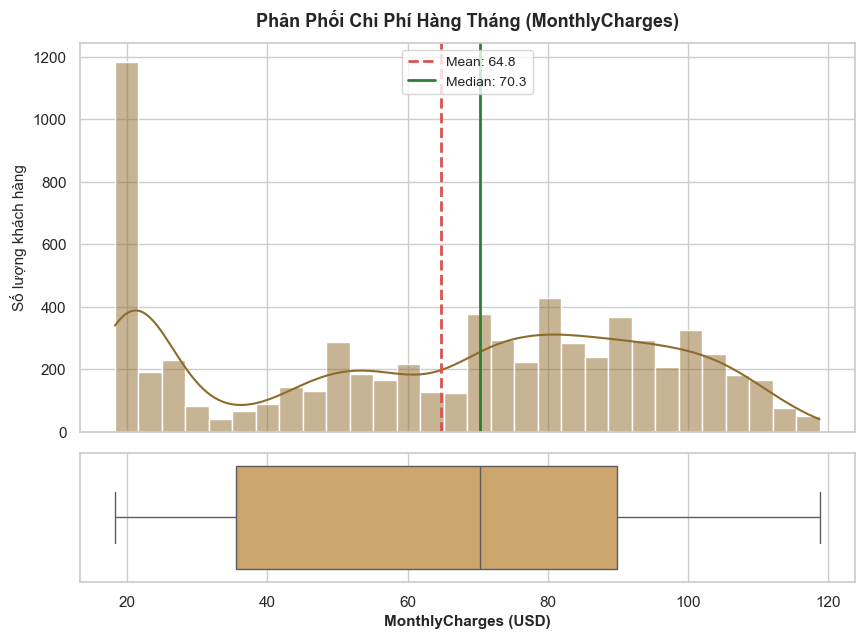



=== BẢNG THỐNG KÊ MÔ TẢ BIẾN TOTALCHARGES ===
          Chỉ số Thống kê  Giá trị (USD)
        Trung bình (Mean)       2279.730
        Trung vị (Median)       1394.550
           Nhỏ nhất (Min)          0.000
           Lớn nhất (Max)       8684.800
      Độ lệch chuẩn (Std)       2266.790
        Tứ phân vị 1 (Q1)        398.550
        Tứ phân vị 3 (Q3)       3786.600
  Khoảng tứ phân vị (IQR)       3388.050
       Độ lệch (Skewness)          0.960
Độ nhọn (Excess Kurtosis)         -0.230


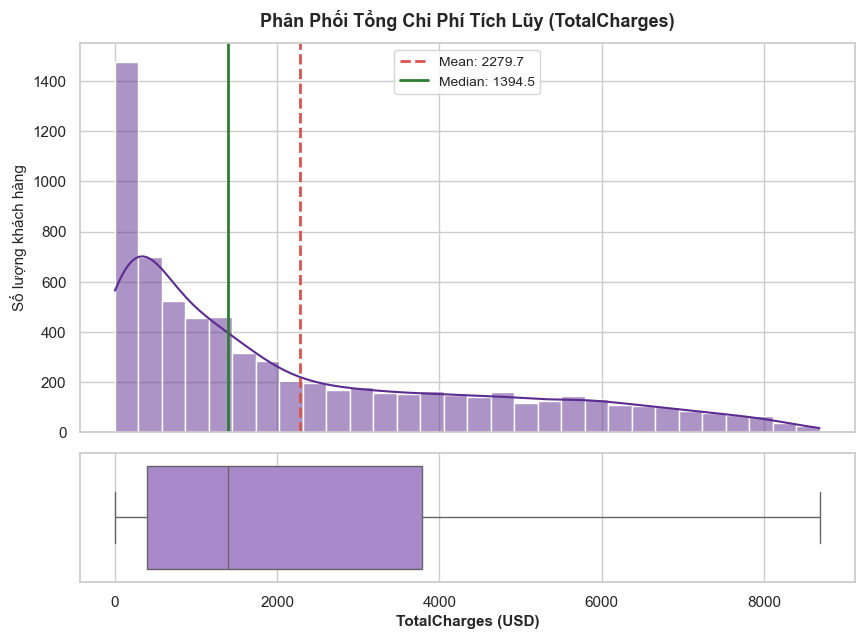

In [5]:
# Thiết lập giao diện Seaborn
sns.set_theme(style='whitegrid')


def phan_tich_don_bien_so(df, col_name, unit='', color_hist='#2b5c8f',
                           color_box='#6baed6', bins=30, title=None,
                           save_path=None, show=True):
    """
    Hàm tổng quát: Phân tích đơn biến cho MỘT biến số bất kỳ trong dataset.
    Bao gồm 2 phần:
        1. Tính toán bảng thống kê mô tả (Mean, Median, Std, Skewness, Kurtosis...)
        2. Trực quan hóa (Histogram + KDE + Boxplot)
    """
    series = df[col_name].dropna()

    # =====================================================================
    # 1. TÍNH TOÁN CÁC CHỈ SỐ THỐNG KÊ MÔ TẢ
    # =====================================================================
    mean_val = series.mean()
    median_val = series.median()
    min_val = series.min()
    max_val = series.max()
    std_val = series.std()
    q1_val = series.quantile(0.25)
    q3_val = series.quantile(0.75)
    iqr_val = q3_val - q1_val
    skew_val = stats.skew(series, nan_policy='omit')
    kurt_val = stats.kurtosis(series, nan_policy='omit')  # Excess Kurtosis

    don_vi_label = f' ({unit})' if unit else ''
    stats_summary = pd.DataFrame({
        'Chỉ số Thống kê': [
            'Trung bình (Mean)', 'Trung vị (Median)', 'Nhỏ nhất (Min)',
            'Lớn nhất (Max)', 'Độ lệch chuẩn (Std)', 'Tứ phân vị 1 (Q1)',
            'Tứ phân vị 3 (Q3)', 'Khoảng tứ phân vị (IQR)',
            'Độ lệch (Skewness)', 'Độ nhọn (Excess Kurtosis)'
        ],
        f'Giá trị{don_vi_label}': [
            round(mean_val, 2), round(median_val, 2), round(min_val, 2),
            round(max_val, 2), round(std_val, 2), round(q1_val, 2),
            round(q3_val, 2), round(iqr_val, 2), round(skew_val, 2),
            round(kurt_val, 2)
        ]
    })

    print(f"=== BẢNG THỐNG KÊ MÔ TẢ BIẾN {col_name.upper()} ===")
    print(stats_summary.to_string(index=False))

    # =====================================================================
    # 2. TRỰC QUAN HÓA (HISTOGRAM + BOXPLOT)
    # =====================================================================
    fig, (ax_hist, ax_box) = plt.subplots(
        nrows=2, ncols=1, figsize=(10, 7), sharex=True,
        gridspec_kw={'height_ratios': [3, 1]}
    )

    # Biểu đồ 1: Histogram + Đường KDE
    sns.histplot(series, kde=True, ax=ax_hist, color=color_hist,
                 bins=bins, edgecolor='white')
    plot_title = title or f'Phân Phối Biến {col_name}'
    ax_hist.set_title(plot_title, fontsize=13, fontweight='bold', pad=12)
    ax_hist.set_ylabel('Số lượng khách hàng', fontsize=11)

    # Đánh dấu đường Mean và Median lên Histogram
    ax_hist.axvline(mean_val, color='#d9534f', linestyle='--', linewidth=2,
                     label=f'Mean: {mean_val:.1f}')
    ax_hist.axvline(median_val, color='#2e7d32', linestyle='-', linewidth=2,
                     label=f'Median: {median_val:.1f}')
    ax_hist.legend(fontsize=10, loc='upper center')

    # Biểu đồ 2: Boxplot kiểm tra Outliers
    sns.boxplot(x=series, ax=ax_box, color=color_box, fliersize=6)
    xlabel_text = f'{col_name}{don_vi_label}'
    ax_box.set_xlabel(xlabel_text, fontsize=11, fontweight='bold')

    plt.subplots_adjust(hspace=0.08)

    # Lưu file an toàn nếu truyền save_path
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True) if os.path.dirname(save_path) else None
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Đã lưu biểu đồ tại: {save_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return stats_summary


# =============================================================================
# THỰC THI CHO CẢ 3 BIẾN SỐ: tenure, MonthlyCharges, TotalCharges
# =============================================================================
# 1. Đọc dữ liệu
df1 = pd.read_csv('Telco Customers Churn Dataset 1.csv')

# 2. Đảm bảo ép kiểu số an toàn cho TotalCharges
df1['TotalCharges'] = pd.to_numeric(df1['TotalCharges'], errors='coerce').fillna(0)

# 3. Cấu hình riêng cho từng biến
cau_hinh_bien = [
    {'col_name': 'tenure', 'unit': 'Tháng',
     'title': 'Phân Phối Thời Gian Gắn Bó Của Khách Hàng (Tenure)',
     'color_hist': '#2b5c8f', 'color_box': '#6baed6'},
    {'col_name': 'MonthlyCharges', 'unit': 'USD',
     'title': 'Phân Phối Chi Phí Hàng Tháng (MonthlyCharges)',
     'color_hist': '#8f6b2b', 'color_box': '#dba95b'},
    {'col_name': 'TotalCharges', 'unit': 'USD',
     'title': 'Phân Phối Tổng Chi Phí Tích Lũy (TotalCharges)',
     'color_hist': '#5c2b8f', 'color_box': '#a97ed4'},
]


ket_qua_tong_hop = {}
for cfg in cau_hinh_bien:
    save_path = None #f"Thongke_{cfg['col_name']}.png" # Lưu ngay tại thư mục hiện tại
    summary = phan_tich_don_bien_so(
        df=df1, save_path=save_path, show=True, **cfg # Đặt show=True để hiển thị trong Jupyter
    )
    ket_qua_tong_hop[cfg['col_name']] = summary
    print("\n" + "="*60 + "\n")

PHẦN A: BIẾN ĐỊNH LƯỢNG vs CHURN
=== KẾT QUẢ MANN-WHITNEY U: BIẾN ĐỊNH LƯỢNG vs Churn ===


,Biến,Mean (Churn=Yes),Mean (Churn=No),U-statistic,p-value,Ý nghĩa TK (p<0.05)
0,tenure,17.980,37.570,2515538.000,0.000,Có
1,MonthlyCharges,74.440,61.270,6003125.500,0.000,Có
2,TotalCharges,1531.800,2549.910,3381224.000,0.000,Có


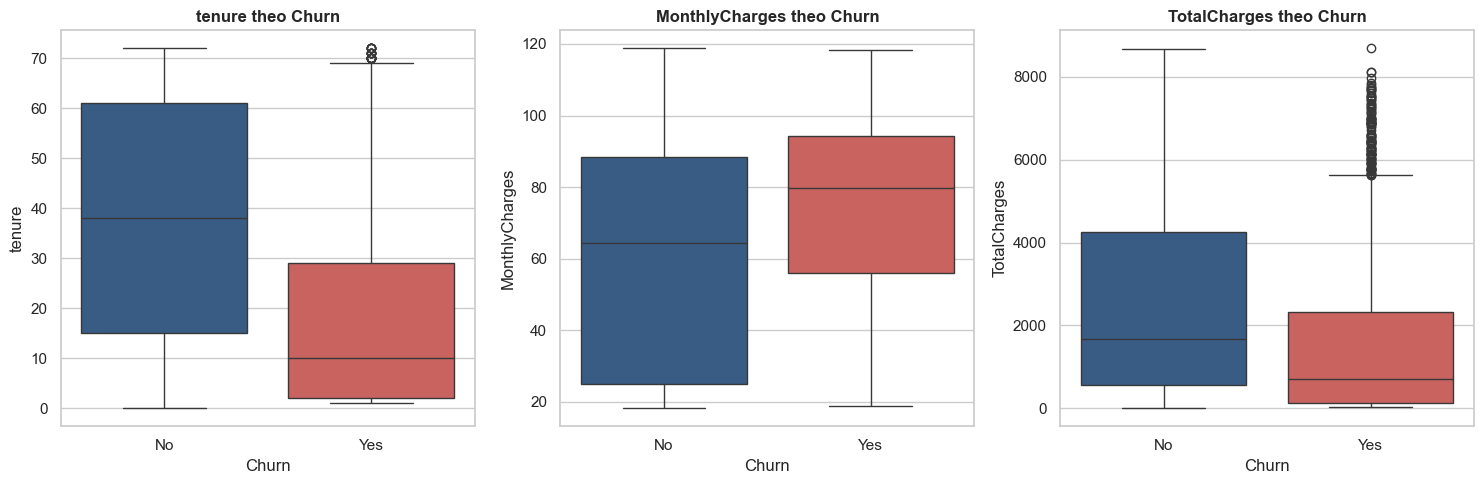

PHẦN B: BIẾN PHÂN LOẠI vs CHURN
=== KẾT QUẢ CHI-SQUARE TEST: BIẾN PHÂN LOẠI vs Churn ===


,Biến,Chi2,p-value,Ý nghĩa TK (p<0.05)
0,Contract,1184.600,0.000,Có
1,OnlineSecurity,850.000,0.000,Có
2,TechSupport,828.200,0.000,Có
3,InternetService,732.310,0.000,Có
4,PaymentMethod,648.140,0.000,Có
5,OnlineBackup,601.810,0.000,Có
6,DeviceProtection,558.420,0.000,Có
7,StreamingMovies,375.660,0.000,Có
8,StreamingTV,374.200,0.000,Có
9,PaperlessBilling,258.280,0.000,Có


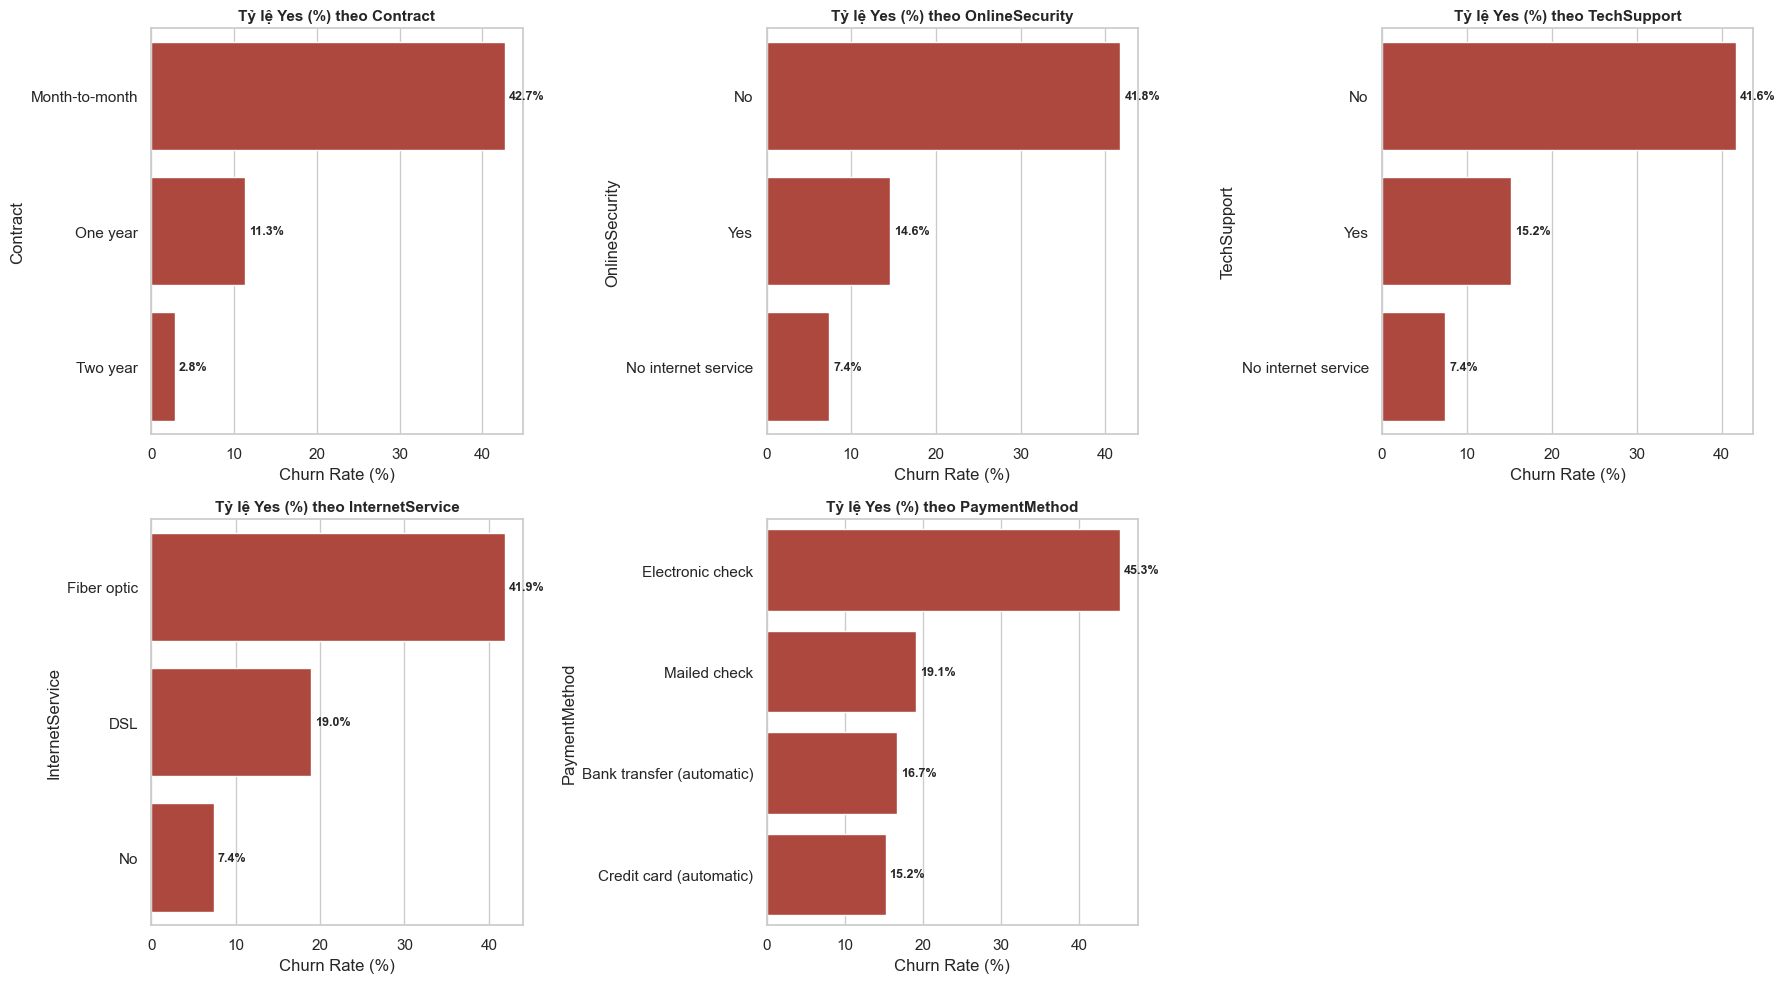

PHẦN C: MA TRẬN TƯƠNG QUAN
=== MA TRẬN TƯƠNG QUAN PEARSON ===


,tenure,MonthlyCharges,TotalCharges,Churn_binary
tenure,1.000,0.248,0.826,-0.352
MonthlyCharges,0.248,1.000,0.651,0.193
TotalCharges,0.826,0.651,1.000,-0.198
Churn_binary,-0.352,0.193,-0.198,1.000


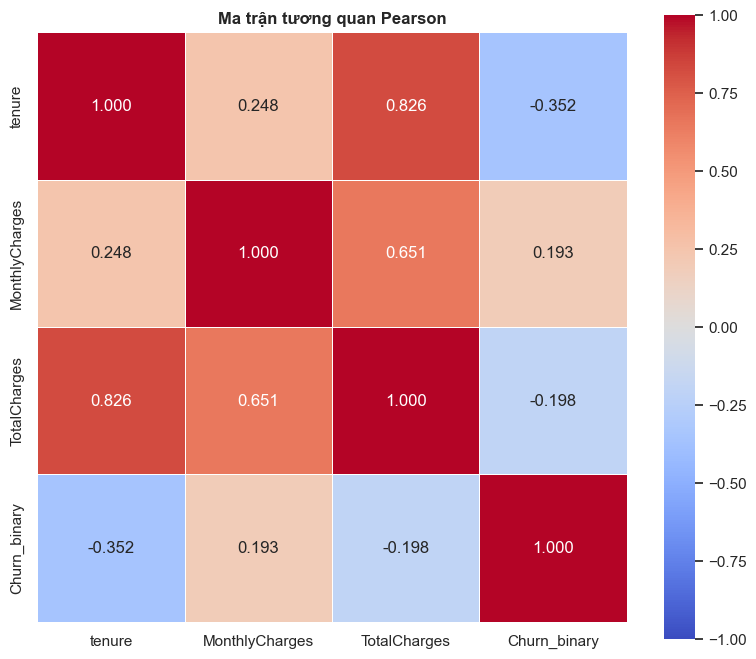

In [6]:

# Cấu hình giao diện Seaborn
sns.set_theme(style='whitegrid')

# =============================================================================
# HÀM A: PHÂN TÍCH BIẾN ĐỊNH LƯỢNG vs BIẾN MỤC TIÊU (Mann-Whitney U Test)
# =============================================================================
def phan_tich_dinh_luong_vs_target(df, num_cols, target_col, positive_label='Yes',
                                    negative_label='No', save_path=None, show=True):
    results = []
    for col in num_cols:
        group_pos = df[df[target_col] == positive_label][col].dropna()
        group_neg = df[df[target_col] == negative_label][col].dropna()
        u_stat, p_val = stats.mannwhitneyu(group_pos, group_neg, alternative='two-sided')
        results.append({
            'Biến': col,
            f'Mean ({target_col}={positive_label})': round(group_pos.mean(), 2),
            f'Mean ({target_col}={negative_label})': round(group_neg.mean(), 2),
            'U-statistic': round(u_stat, 2),
            'p-value': p_val,
            'Ý nghĩa TK (p<0.05)': 'Có' if p_val < 0.05 else 'Không'
        })

    result_df = pd.DataFrame(results)
    print(f"=== KẾT QUẢ MANN-WHITNEY U: BIẾN ĐỊNH LƯỢNG vs {target_col} ===")
    display(result_df)
    print("\n")

    # ---- Trực quan hóa: Boxplot ----
    n = len(num_cols)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]

    palette = {positive_label: '#d9534f', negative_label: '#2b5c8f'}
    for ax, col in zip(axes, num_cols):
        sns.boxplot(data=df, x=target_col, y=col, ax=ax, hue=target_col, palette=palette, legend=False)
        ax.set_title(f'{col} theo {target_col}', fontsize=12, fontweight='bold')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Đã lưu biểu đồ tại: {save_path}")
    if show:
        plt.show()
    else:
        plt.close(fig)

    return result_df


# =============================================================================
# HÀM B: PHÂN TÍCH BIẾN PHÂN LOẠI vs BIẾN MỤC TIÊU (Chi-square Test)
# =============================================================================
def phan_tich_phan_loai_vs_target(df, cat_cols, target_col, positive_label='Yes',
                                    top_n_ve_bieu_do=5, save_path=None, show=True):
    chi2_results = []
    for col in cat_cols:
        contingency = pd.crosstab(df[col], df[target_col])
        chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
        chi2_results.append({
            'Biến': col, 
            'Chi2': round(chi2, 2), 
            'p-value': p_val,
            'Ý nghĩa TK (p<0.05)': 'Có' if p_val < 0.05 else 'Không'
        })

    chi2_df = pd.DataFrame(chi2_results).sort_values('Chi2', ascending=False).reset_index(drop=True)
    print(f"=== KẾT QUẢ CHI-SQUARE TEST: BIẾN PHÂN LOẠI vs {target_col} ===")
    display(chi2_df)
    print("\n")

    # ---- Trực quan hóa Top N biến ----
    top_vars = chi2_df.head(top_n_ve_bieu_do)['Biến'].tolist()
    n_cols_grid = 3
    n_rows_grid = int(np.ceil(len(top_vars) / n_cols_grid))
    fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(6 * n_cols_grid, 5 * n_rows_grid))
    axes = np.array(axes).flatten()

    for i, col in enumerate(top_vars):
        # Tính tỷ lệ Churn (%) an toàn theo từng nhóm
        rate = df.groupby(col)[target_col].apply(
            lambda x: (x == positive_label).mean() * 100
        ).sort_values(ascending=False)

        sns.barplot(x=rate.values, y=rate.index, ax=axes[i], color='#c0392b')
        axes[i].set_title(f'Tỷ lệ {positive_label} (%) theo {col}', fontsize=11, fontweight='bold')
        axes[i].set_xlabel(f'{target_col} Rate (%)')
        
        for j, v in enumerate(rate.values):
            axes[i].text(v + 0.5, j, f'{v:.1f}%', va='center', fontsize=9, fontweight='bold')

    # Ẩn các ô thừa trong lưới
    for k in range(len(top_vars), len(axes)):
        axes[k].axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Đã lưu biểu đồ tại: {save_path}")
    if show:
        plt.show()
    else:
        plt.close(fig)

    return chi2_df


# =============================================================================
# HÀM C: MA TRẬN TƯƠNG QUAN
# =============================================================================
def ma_tran_tuong_quan(df, num_cols, target_col=None, positive_label='Yes',
                        save_path=None, show=True):
    cols_to_use = num_cols.copy()
    df_temp = df.copy()

    if target_col:
        target_bin_col = f'{target_col}_binary'
        df_temp[target_bin_col] = (df_temp[target_col] == positive_label).astype(int)
        cols_to_use = cols_to_use + [target_bin_col]

    corr_matrix = df_temp[cols_to_use].corr()
    print("=== MA TRẬN TƯƠNG QUAN PEARSON ===")
    display(corr_matrix.round(3))
    print("\n")

    fig, ax = plt.subplots(figsize=(1.5 * len(cols_to_use) + 2, 1.2 * len(cols_to_use) + 2))
    sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
                square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
    ax.set_title('Ma trận tương quan Pearson', fontsize=12, fontweight='bold')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Đã lưu biểu đồ tại: {save_path}")
    if show:
        plt.show()
    else:
        plt.close(fig)

    return corr_matrix


# =============================================================================
# THỰC THI TRÊN JUPYTERLAB
# =============================================================================
# 1. Đọc dữ liệu từ file local
df = pd.read_csv('Telco Customers Churn Dataset 1.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
            'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaperlessBilling', 'PaymentMethod']

# 2. Chạy Phần A (Bật show=True)
print("="*70)
print("PHẦN A: BIẾN ĐỊNH LƯỢNG vs CHURN")
print("="*70)
ket_qua_A = phan_tich_dinh_luong_vs_target(
    df, num_cols=num_cols, target_col='Churn',
    positive_label='Yes', negative_label='No',
    save_path= None, show=True
)

# 3. Chạy Phần B (Bật show=True)
print("="*70)
print("PHẦN B: BIẾN PHÂN LOẠI vs CHURN")
print("="*70)
ket_qua_B = phan_tich_phan_loai_vs_target(
    df, cat_cols=cat_cols, target_col='Churn', positive_label='Yes',
    top_n_ve_bieu_do=5,
    save_path=None, show=True
)

# 4. Chạy Phần C (Bật show=True)
print("="*70)
print("PHẦN C: MA TRẬN TƯƠNG QUAN")
print("="*70)
ket_qua_C = ma_tran_tuong_quan(
    df, num_cols=num_cols, target_col='Churn', positive_label='Yes',
    save_path=None, show=True
)

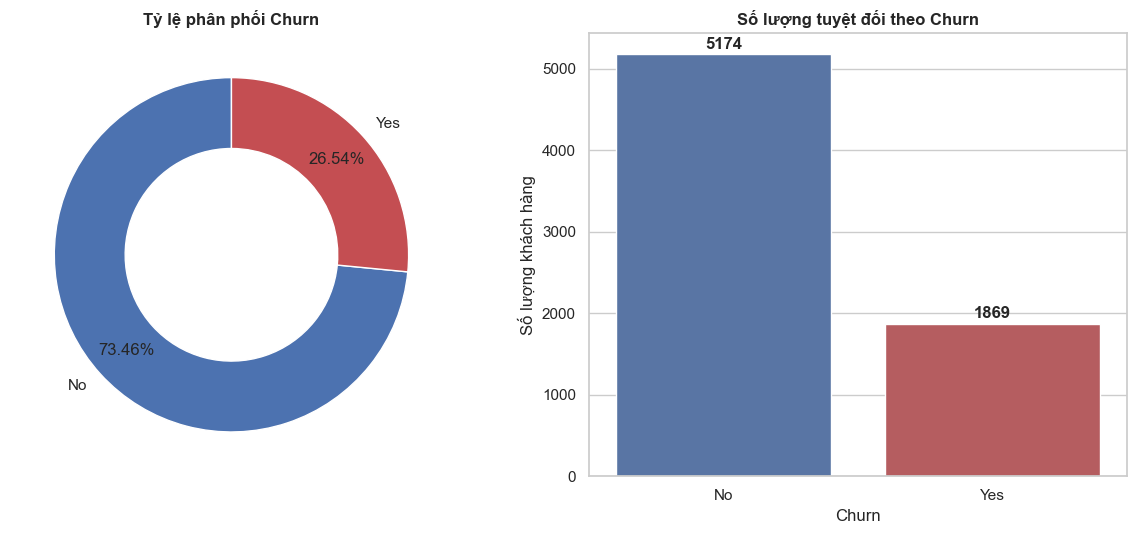


=== ĐỊNH LƯỢNG MẤT CÂN BẰNG - BIẾN CHURN ===
Lớp đa số  (No): 5174 (73.46%)
Lớp thiểu số (Yes): 1869 (26.54%)
Imbalance Ratio (IR) = 2.77  →  Mức độ: Nhẹ (Mild)

--- ACCURACY PARADOX ---
Mô hình 'ngây thơ' luôn dự đoán 'No':
   → Accuracy = 73.46%  |  Recall(lớp Yes) = 0%


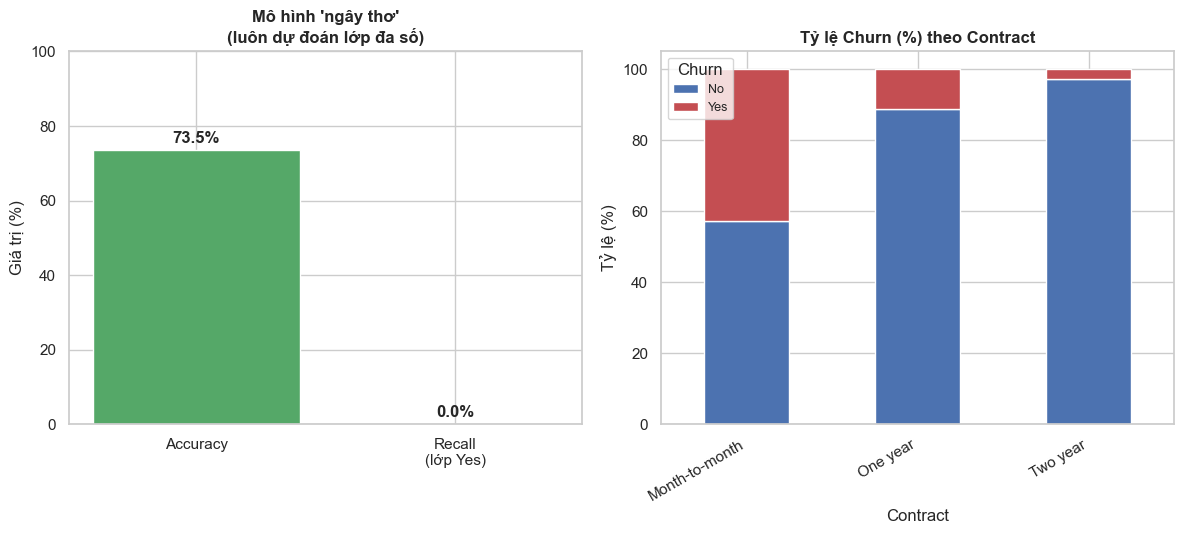


Tổng hợp kết quả định lượng: {'counts': Churn
No     5174
Yes    1869
Name: count, dtype: int64, 'total': 7043, 'majority_label': 'No', 'minority_label': 'Yes', 'majority_n': 5174, 'minority_n': 1869, 'ir': 2.77, 'muc_do': 'Nhẹ (Mild)', 'accuracy_naive': 73.46}


In [11]:
sns.set_theme(style='whitegrid')


def tinh_toan_mat_can_bang(df, target_col, positive_label='Yes', negative_label='No'):
    """
    Tính các chỉ số định lượng mất cân bằng (dùng chung cho cả 2 hàm vẽ bên dưới).

    Trả về
    -------
    dict chứa: counts, majority_label, minority_label, majority_n, minority_n,
               ir (Imbalance Ratio), muc_do, accuracy_naive
    """
    counts = df[target_col].value_counts()
    total = len(df)
    majority_label = counts.idxmax()
    minority_label = counts.idxmin()
    majority_n, minority_n = counts.max(), counts.min()

    ir = majority_n / minority_n
    if ir < 4:
        muc_do = 'Nhẹ (Mild)'
    elif ir < 20:
        muc_do = 'Trung bình (Moderate)'
    else:
        muc_do = 'Nghiêm trọng (Extreme)'

    accuracy_naive = majority_n / total * 100

    print(f"=== ĐỊNH LƯỢNG MẤT CÂN BẰNG - BIẾN {target_col.upper()} ===")
    print(f"Lớp đa số  ({majority_label}): {majority_n} ({majority_n/total*100:.2f}%)")
    print(f"Lớp thiểu số ({minority_label}): {minority_n} ({minority_n/total*100:.2f}%)")
    print(f"Imbalance Ratio (IR) = {ir:.2f}  →  Mức độ: {muc_do}")
    print(f"\n--- ACCURACY PARADOX ---")
    print(f"Mô hình 'ngây thơ' luôn dự đoán '{majority_label}':")
    print(f"   → Accuracy = {accuracy_naive:.2f}%  |  Recall(lớp {minority_label}) = 0%")

    return {
        'counts': counts, 'total': total,
        'majority_label': majority_label, 'minority_label': minority_label,
        'majority_n': majority_n, 'minority_n': minority_n,
        'ir': round(ir, 2), 'muc_do': muc_do, 'accuracy_naive': round(accuracy_naive, 2)
    }


def ve_phan_phoi_tong_quan(df, target_col, save_path=None, show=True):
    """
    ẢNH 1: Trực quan hóa phân phối tổng quan biến mục tiêu.
        - Donut Chart: tỷ lệ % giữa các lớp
        - Bar Chart: số lượng tuyệt đối từng lớp

    Tham số
    ----------
    df : pd.DataFrame
    target_col : str
        Tên cột biến mục tiêu (vd: 'Churn').
    save_path : str, optional
    show : bool, optional

    Trả về
    -------
    pd.Series : counts (số lượng theo từng lớp)
    """
    counts = df[target_col].value_counts()
    total = len(df)
    colors = ['#4C72B0', '#C44E52']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))

    # --- Donut Chart tỷ lệ % ---
    ax1.pie(
        counts.values, labels=counts.index, autopct='%1.2f%%',
        startangle=90, colors=colors, pctdistance=0.8,
        wedgeprops={'width': 0.4, 'edgecolor': 'white'}
    )
    ax1.set_title(f'Tỷ lệ phân phối {target_col}', fontsize=12, fontweight='bold')

    # --- Bar Chart số lượng tuyệt đối ---
    sns.barplot(x=counts.index, y=counts.values, hue=counts.index,
                ax=ax2, palette=colors, legend=False)
    ax2.set_title(f'Số lượng tuyệt đối theo {target_col}', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Số lượng khách hàng')
    for i, v in enumerate(counts.values):
        ax2.text(i, v + total*0.01, f'{v}', ha='center', fontweight='bold')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Đã lưu biểu đồ (Ảnh 1 - Phân phối tổng quan) tại: {save_path}")
    if show:
        plt.show()
    plt.close(fig)

    return counts


def ve_paradox_va_phan_khuc(df, target_col, positive_label='Yes', negative_label='No',
                             segment_col=None, save_path=None, show=True):
    """
    ẢNH 2: Minh họa hệ lụy mất cân bằng + góc nhìn phân khúc.
        - Bar Chart: Accuracy Paradox (Accuracy vs Recall của mô hình 'ngây thơ')
        - (Tùy chọn) Stacked Bar Chart: tỷ lệ target theo từng phân khúc (segment_col)

    Tham số
    ----------
    df : pd.DataFrame
    target_col : str
    positive_label, negative_label : str
    segment_col : str, optional
        Nếu có, vẽ thêm biểu đồ mất cân bằng theo từng nhóm (vd: 'Contract').
    save_path : str, optional
    show : bool, optional

    Trả về
    -------
    dict : kết quả định lượng (ir, muc_do, accuracy_naive...)
    """
    ket_qua = tinh_toan_mat_can_bang(df, target_col, positive_label, negative_label)
    minority_label = ket_qua['minority_label']
    accuracy_naive = ket_qua['accuracy_naive']
    colors = ['#4C72B0', '#C44E52']

    n_plots = 1 if segment_col is None else 2
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5.5))
    if n_plots == 1:
        axes = [axes]

    # --- Biểu đồ 1: Minh họa Accuracy Paradox ---
    metrics = ['Accuracy', f'Recall\n(lớp {minority_label})']
    values = [accuracy_naive, 0]
    bars = axes[0].bar(metrics, values, color=['#55a868', '#C44E52'])
    axes[0].set_title("Mô hình 'ngây thơ'\n(luôn dự đoán lớp đa số)", fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Giá trị (%)')
    axes[0].set_ylim(0, 100)
    for bar, v in zip(bars, values):
        axes[0].text(bar.get_x()+bar.get_width()/2, v+2, f'{v:.1f}%', ha='center', fontweight='bold')

    # --- Biểu đồ 2 (tùy chọn): Mất cân bằng theo phân khúc ---
    if segment_col is not None:
        cross = pd.crosstab(df[segment_col], df[target_col], normalize='index') * 100
        cross.plot(kind='bar', stacked=True, ax=axes[1], color=colors)
        axes[1].set_title(f'Tỷ lệ {target_col} (%) theo {segment_col}', fontsize=12, fontweight='bold')
        axes[1].set_ylabel('Tỷ lệ (%)')
        axes[1].legend(title=target_col, fontsize=9)
        plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Đã lưu biểu đồ (Ảnh 2 - Paradox & Phân khúc) tại: {save_path}")
    if show:
        plt.show()
    plt.close(fig)

    return ket_qua


# =============================================================================
# GỌI HÀM CHO MỤC 4.1.4
# =============================================================================
if __name__ == '__main__':
    df = pd.read_csv('Telco Customers Churn Dataset 1.csv')

    # ẢNH 1: Phân phối tổng quan (Donut + Bar số lượng)
    counts = ve_phan_phoi_tong_quan(
        df, target_col='Churn',
        save_path=None, show=True
    )

    print()

    # ẢNH 2: Accuracy Paradox + Phân khúc theo Contract
    ket_qua = ve_paradox_va_phan_khuc(
        df, target_col='Churn', positive_label='Yes', negative_label='No',
        segment_col='Contract',
        save_path=None, show=True
    )
    print("\nTổng hợp kết quả định lượng:", ket_qua)